In [58]:
import pandas as pd

filename = "../../data/processed/frogID5_database_prepared.csv"
frogID5_database_final = pd.read_csv(filename, sep=',', on_bad_lines='skip')

In [59]:
### preparing data

species_counts = frogID5_database_final.groupby('vernacularName').size().reset_index(name='counts')
species_counts = species_counts.sort_values(by='counts', ascending=False).set_index('vernacularName')

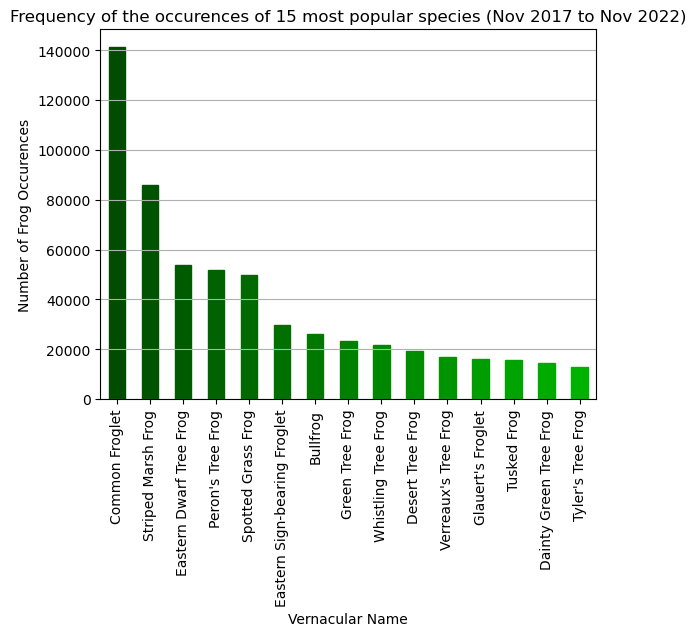

In [60]:
### plotting

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

number_of_bars = 15


frequency_of_most_popular_species  = species_counts.head(number_of_bars).plot(kind='bar')

frequency_of_most_popular_species.set_title('Frequency of the occurences of ' + str(number_of_bars) + ' most popular species (Nov 2017 to Nov 2022)')
frequency_of_most_popular_species.set_xlabel('Vernacular Name')
frequency_of_most_popular_species.set_ylabel('Number of Frog Occurences')

frequency_of_most_popular_species.get_legend().remove()
frequency_of_most_popular_species.grid(True, axis='y')

## coloring the bars
green_shading = []
for i in range(number_of_bars):
    v = 0.3 + (0.4 * (i / (number_of_bars - 1)))
    green_shading.append(mcolors.to_hex(mcolors.hsv_to_rgb((1/3, 1, v))))

bars = frequency_of_most_popular_species.patches
for i in range(len(bars)):
    bars[i].set_color(green_shading[i])  


plt.show()